In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# import database

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

tables= pd.read_sql(sql_query,conn)

# create data frame for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]= df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# data cleaning

In [5]:
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
# a. rename col - name
# b. drop columns - interests and pincode
# c. change data type - dob
# d. Data standardization - gender
# e. Fix missing values - countery 

In [8]:
# a. rename col - name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [9]:
#b drop columns - interest and pincode
#df_db_customer.drop(df_db_customer.columns[-2:], axis = 1)
df_db_customer.drop(columns=['interests' , 'pincode'], inplace=True)

In [10]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [12]:
# c hange Data Type

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [13]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [15]:
# d. data standerdization - gender

df_db_customer['gender']= df_db_customer['gender'].replace({'Men' : 'Male','Women': 'Female'})

In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [17]:
#e. Fix missing values

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [19]:
state_country_mapping  = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [20]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [21]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [22]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [23]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [24]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [25]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [26]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [27]:
df_db_support['complaint_date']= pd.to_datetime(df_db_support['complaint_date'])

In [28]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
 5   comment         4 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 564.0+ bytes


In [29]:
df_db_support.drop(columns =['col_1', 'comment'], inplace = True)

# Feature Engineeringh and data analysis

In [30]:
# Create a new col using existing col - churn flag
df_db_subscription['chur_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1,0)

In [31]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,chur_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [32]:
# first fix duplicate then merge
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how='left')
    .merge(df_db_support, on = 'customerid', how='left') )

In [33]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,chur_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [34]:
df.shape

(23, 20)

In [35]:
df_db_customer['customerid'].nunique()

21

In [36]:
df_db_support['customerid'].nunique()

7

In [37]:
df_db_subscription['customerid'].nunique()

21

In [38]:
df_db_support['customerid'].size

9

In [39]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [40]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [41]:
df_db_support['customerid'].size

7

In [42]:
# merge df

df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how='left')
    .merge(df_db_support, on = 'customerid', how='left') )

In [43]:
df.shape

(21, 21)

In [44]:
df.to_csv('exported_churn_data.csv', index= False)

In [45]:
# Data Analysis

In [46]:
# 1. Churn rate

In [47]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'chur_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [48]:
df.rename(columns = {'chur_flag': 'churn_flag'}, inplace = True)

In [49]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate", round(churn_rate,2), "%")

Churn Rate 28.57 %


In [50]:
# 2. Retention Rate
retention_rate = 100 - churn_rate
print("Retention Rate", round(retention_rate,2), "%")

Retention Rate 71.43 %


In [51]:
# 3. Churn by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [52]:
 # 4. ARPU - Avg Revenue Per User 

In [53]:
arpu = df['monthly_charges'].mean()
print("Avg Revenue Per User ",round(arpu,2))

Avg Revenue Per User  18.85


In [54]:
# Calculate customer age 

In [55]:
# 5. Avg Tenuar 
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days']= np.where(
    df['cancellation_date'].notna(),
 
   (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Ave Tenure (Days) =", round(avg_tenure),0)

Ave Tenure (Days) = 1499 0


In [56]:
#Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at risk (Rs'k') =",revenue_at_risk)

Revenue at risk (Rs'k') = 73.94


In [57]:
# Esclation Rate
escalations_rate= (df['escalations']=='Y').mean()*100
print("Escalation Rate =", round(escalations_rate, 2),"%")

Escalation Rate = 19.05 %


In [58]:
#Avg complaint per user
avg_complains = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complain Per User =", round(avg_complains,2))

Avg Complain Per User = 0.43


In [59]:
# correlation Escalation Vs Churn

df['escalations']=np.where(df['escalations'] == 'Y',1,0) # encoding string to int type
corr_df = df[['escalations','churn_flag']].dropna()

#correlation = 
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation Between escalation vs churn is = ", round(correlation,2))

Correlation Between escalation vs churn is =  0.77


In [60]:
# churn risk- create a column using existing col - churn risk
condition = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >=70)
]

choices = ['low','med','high']

df['churn_risk'] = np.select(condition, choices, default='unknow')

In [61]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1953.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1338.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2628.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [62]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [63]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1953.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high


In [64]:
#4. visualization using matplotlib

In [65]:
df_visual= df.copy()

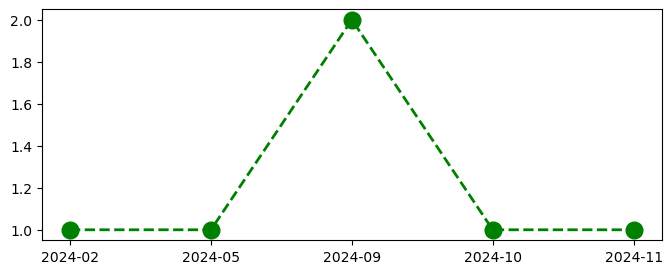

In [66]:
#4.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()


plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color = 'green', marker='o', linestyle='dashed', linewidth=2, markersize=12  )

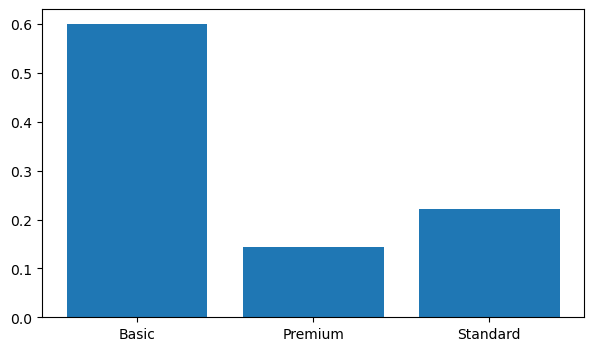

In [67]:
# 4.2 churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values)
plt.show()

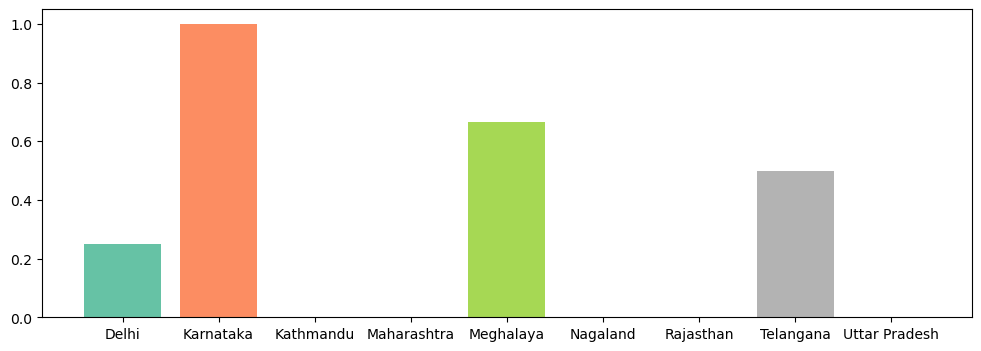

In [68]:
#4.3 churn by states

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors )
plt.show()

In [69]:
# visualization using seaborn

In [70]:
#Encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [71]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [72]:
# incorrect method of encoding - based on priority
df_encoded= df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col]= df_encoded[col].astype('category').cat.codes

C:\Users\yashw\AppData\Local\Temp\ipykernel_27988\3883485982.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]= df_encoded[col].astype('category').cat.codes
C:\Users\yashw\AppData\Local\Temp\ipykernel_27988\3883485982.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]= df_encoded[col].astype('category').cat.codes
C:\Users\yashw\AppData\Local\Temp\ipykernel_27988\3883485982.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [73]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

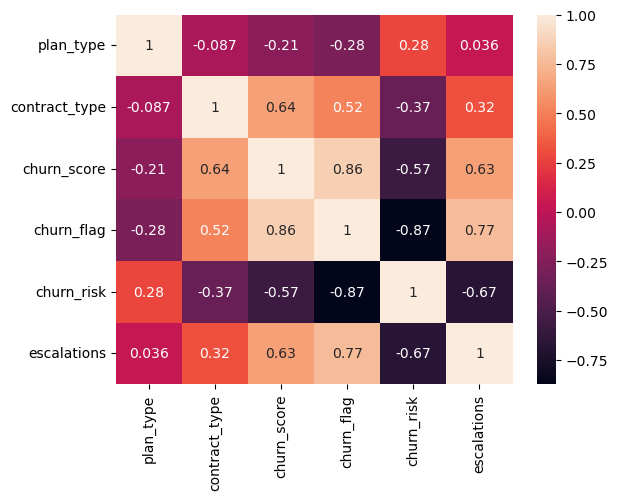

In [74]:
# Heatmap (correlation matrix

sns.heatmap(df_encoded.corr(), annot=True) 

In [75]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [76]:
# correct method of encoding - based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mappings = {
    'plan_type': ['Basic','Standard','Premium'],
    'contract_type': ['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
}

for col, order in order_mappings.items():
    df_encoded[col]= pd.Categorical(df_encoded[col].astype('category'),categories=order, ordered=True).codes

C:\Users\yashw\AppData\Local\Temp\ipykernel_27988\4267632212.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]= pd.Categorical(df_encoded[col].astype('category'),categories=order, ordered=True).codes
C:\Users\yashw\AppData\Local\Temp\ipykernel_27988\4267632212.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]= pd.Categorical(df_encoded[col].astype('category'),categories=order, ordered=True).codes
C:\Users\yashw\AppData\Local\Temp\ipykernel_27988\4267632212.py:11: Settin

In [77]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

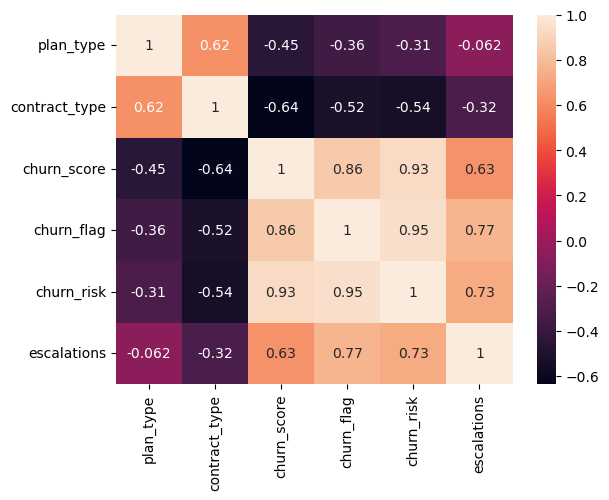

In [78]:
# Heatmap (correlation matrix

sns.heatmap(df_encoded.corr(), annot=True) 

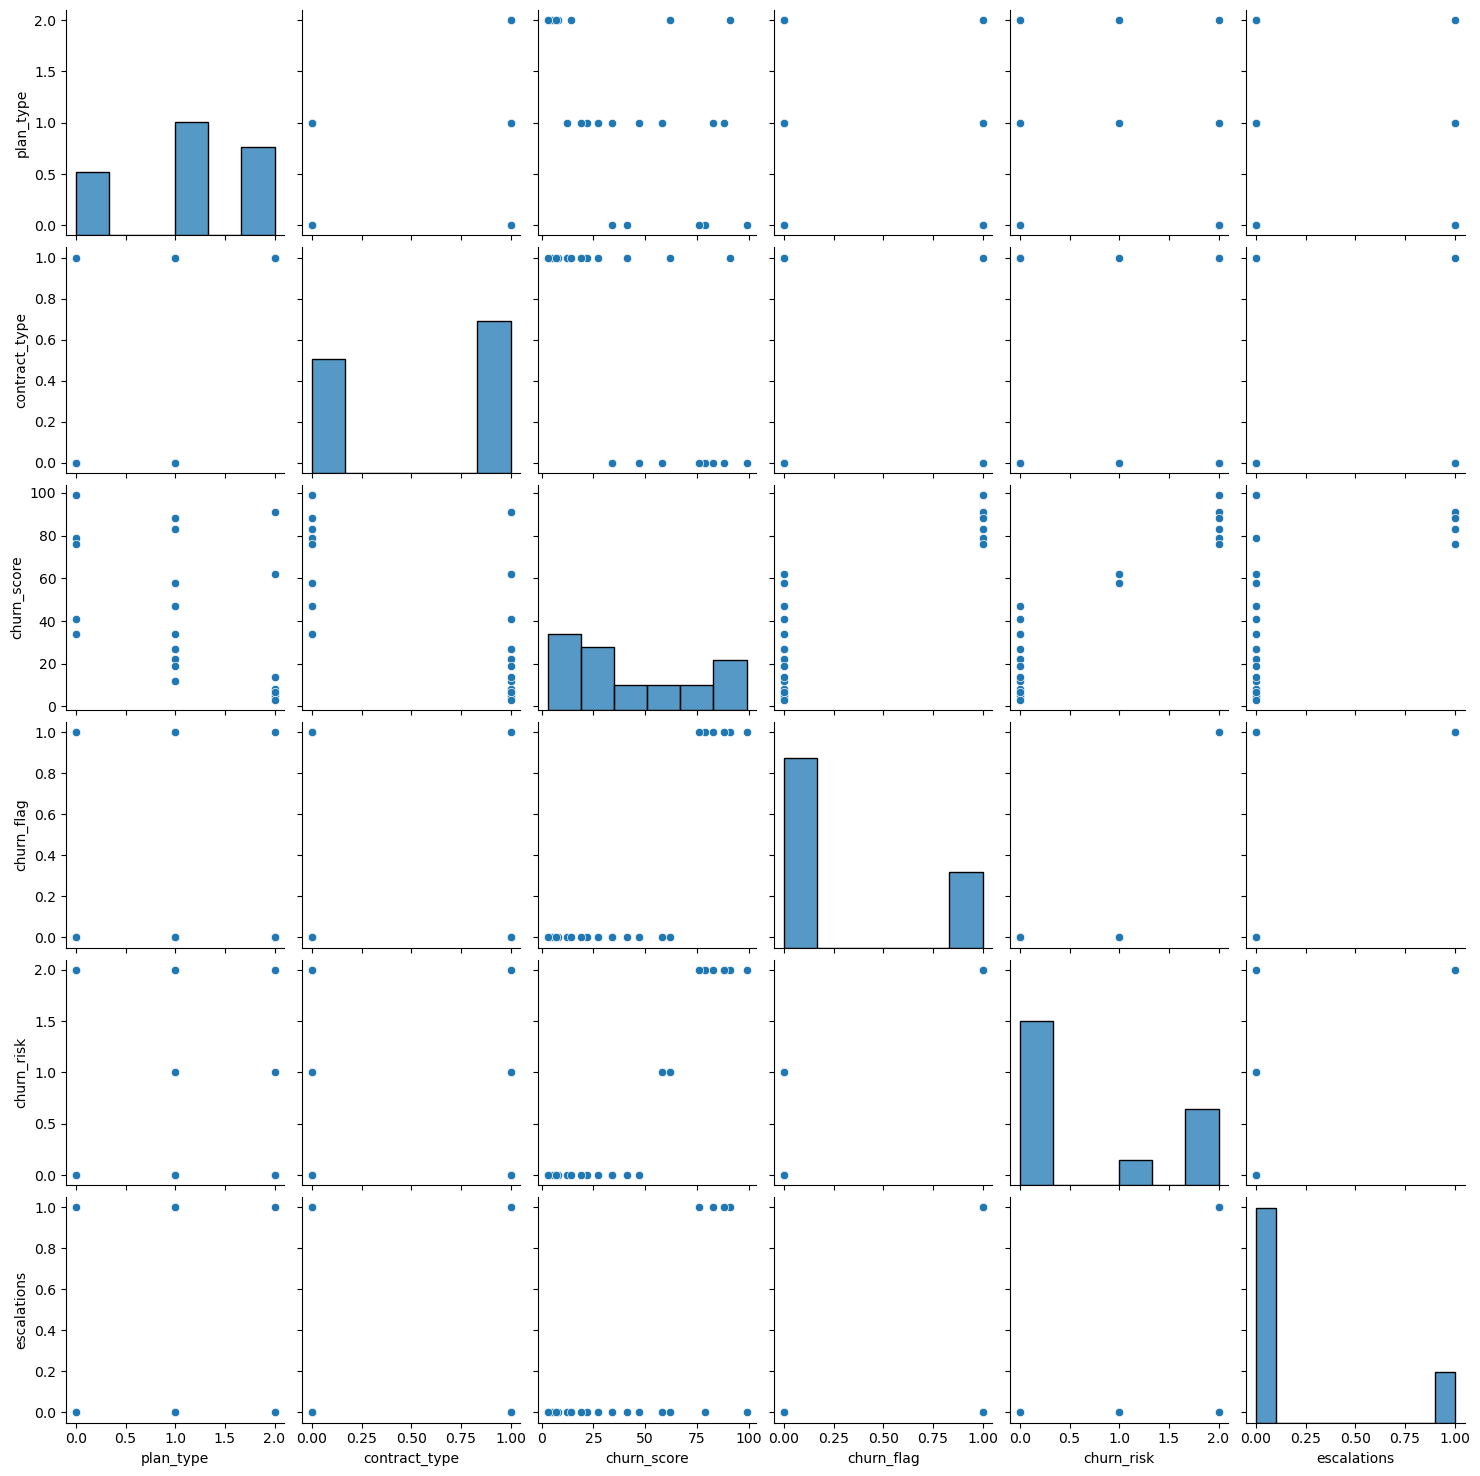

In [79]:
# Pair plot - relationship in dataset
sns.pairplot(df_encoded)

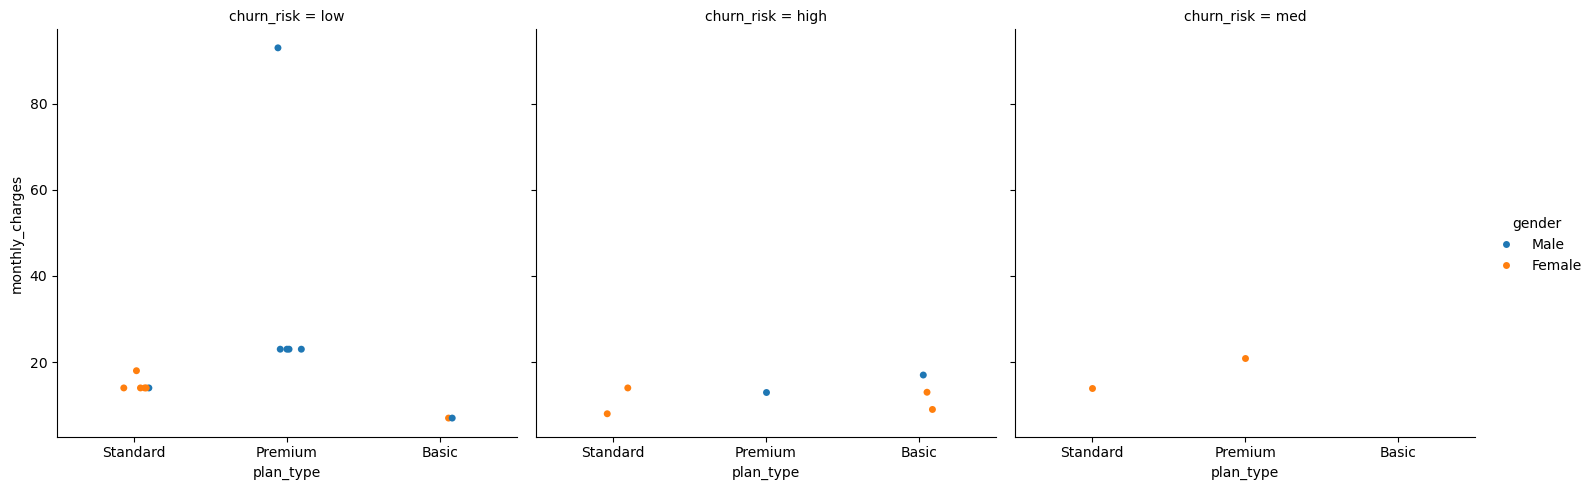

In [80]:
# catplt/facegrid plot 

sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

In [81]:
#Pivort Table

In [82]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
    
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [83]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [84]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
    
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
